### Base rates and the criterion
Run both cells top to bottom. Edit the `👈` value and re-run.

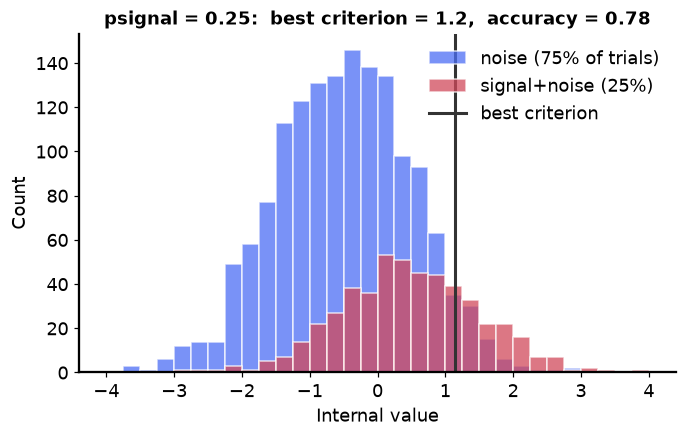

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
NOISE  = "#4c6ef5"   # signal-absent (noise) trials
SIGNAL = "#d1495b"   # signal-present trials
CRIT   = "#333333"   # criterion / theory lines

ntrials         = 2000
psignal         = 0.25    # 👈 proportion of signal-present trials (try 0.1 ... 0.9)
signal_strength = 1
noise_mean, noise_sd = -0.5, 1

rng = np.random.default_rng()
n_noise = round(ntrials * (1 - psignal))
noise = rng.standard_normal(ntrials) * noise_sd + noise_mean
noise_samps  = noise[:n_noise]                    # signal-absent trials
signal_samps = noise[n_noise:] + signal_strength  # signal-present trials

# find the criterion that maximises accuracy FOR THIS base rate
grid = np.linspace(-2.5, 2.5, 101)
acc  = [(np.sum(noise_samps <= c) + np.sum(signal_samps > c)) / ntrials for c in grid]
best_criterion = grid[int(np.argmax(acc))]
best_accuracy  = max(acc)

bins = np.arange(-4, 4 + 0.25, 0.25)
plt.figure(figsize=(7, 4))
plt.hist(noise_samps,  bins=bins, color=NOISE,  alpha=0.75, edgecolor="white",
         label=f"noise ({100*(1-psignal):.0f}% of trials)")
plt.hist(signal_samps, bins=bins, color=SIGNAL, alpha=0.75, edgecolor="white",
         label=f"signal+noise ({100*psignal:.0f}%)")
plt.axvline(best_criterion, color=CRIT, lw=2, label="best criterion")
plt.xlabel("Internal value")
plt.ylabel("Count")
plt.title(f"psignal = {psignal:.2g}:  best criterion = {best_criterion:.2g},  accuracy = {best_accuracy:.2g}")
plt.legend()
plt.show()


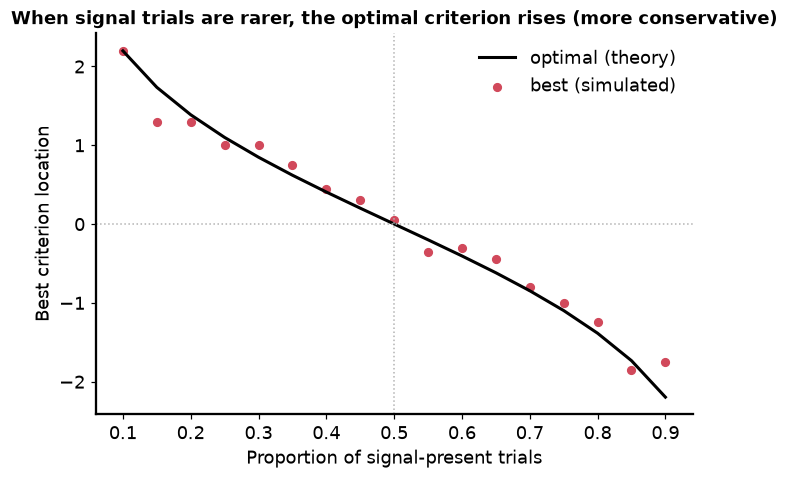

In [2]:
# How does the BEST criterion depend on the proportion of signal trials?
psignals = np.linspace(0.1, 0.9, 17)
grid = np.linspace(-2.5, 2.5, 101)
best_criteria = np.full(psignals.size, np.nan)

for i, p in enumerate(psignals):
    nn = round(ntrials * (1 - p))
    ns = rng.standard_normal(nn)           * noise_sd + noise_mean
    ss = rng.standard_normal(ntrials - nn) * noise_sd + noise_mean + signal_strength
    a  = [(np.sum(ns <= c) + np.sum(ss > c)) / ntrials for c in grid]
    best_criteria[i] = grid[int(np.argmax(a))]

# theoretical optimum for equal-variance gaussians
signal_mean = noise_mean + signal_strength
midpoint = 0.5 * (noise_mean + signal_mean)
theory = midpoint + (noise_sd**2 / (signal_mean - noise_mean)) * np.log((1 - psignals) / psignals)

plt.figure(figsize=(7, 4.5))
plt.plot(psignals, theory, color="k", lw=2, label="optimal (theory)")
plt.scatter(psignals, best_criteria, 25, color=SIGNAL, label="best (simulated)")
plt.axhline(0, color="0.7", ls=":", lw=1)
plt.axvline(0.5, color="0.7", ls=":", lw=1)
plt.xlabel("Proportion of signal-present trials")
plt.ylabel("Best criterion location")
plt.title("When signal trials are rarer, the optimal criterion rises (more conservative)")
plt.legend()
plt.show()
